In [3]:
#!/usr/bin/env python  # 指定脚本使用的解释器
# coding: utf-8  # 指定源文件编码为 UTF-8，支持中文注释
%cd D:\大学\博士论文\GNN部分\07_RA-STGNN

import hues  # 自定义或第三方库，提供快速信息输出功能（例如 hues.info）
import numpy as np  # 导入 NumPy，用于数值计算和数组操作
import pandas as pd  # 导入 Pandas，用于数据处理和 DataFrame 操作

import matplotlib.pyplot as plt  # 导入 Matplotlib 的 pyplot，用于绘图
import matplotlib.dates as mdates  # 导入日期绘图工具，便于时间序列刻度格式化
from matplotlib.lines import Line2D  # 导入 Line2D，用于自定义图例标记
from tools import downsample_block, ATTACK_EVENTS_SWAT  # 从本地工具模块导入下采样函数和攻击事件列表


C:\Users\MR.long\AppData\Roaming\Python\Python39\site-packages\IPython\core\magics\osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


D:\大学\博士论文\GNN部分\07_RA-STGNN


In [5]:
df = pd.read_pickle('D:/大学/博士论文/GNN部分/07_RA-STGNN/Data/Swat/swat_data_10s.pkl')  # 从 pickle 文件加载数据到 DataFrame，路径为 SWAT 数据（注意路径分隔符）
hues.info(df.shape)  # 打印数据形状信息，便于检查行列数
df.head()  # 显示 DataFrame 前几行，快速查看列名和数据示例


09:44:40 - INFO - (94673, 54)


,Timestamp,Attack,Train,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,...,FIT504,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603
0,2015-12-22 16:00:00,0,1,2.479006,260.68542,2.0,2.0,1.0,244.48859,8.190080,...,0.0,1.0,1.0,10.029480,0.0,4.277749,0.000256,1.0,1.0,1.0
1,2015-12-22 16:00:10,0,1,2.619607,261.36449,2.0,2.0,1.0,244.95640,8.190080,...,0.0,1.0,1.0,10.029480,0.0,4.277749,0.000256,1.0,1.0,1.0
2,2015-12-22 16:00:20,0,1,2.482433,262.00037,2.0,2.0,1.0,245.44990,8.192226,...,0.0,1.0,1.0,10.048706,0.0,4.277749,0.000256,1.0,1.0,1.0
3,2015-12-22 16:00:30,0,1,2.573135,262.40076,2.0,2.0,1.0,245.68057,8.193604,...,0.0,1.0,1.0,10.056717,0.0,4.277749,0.000256,1.0,1.0,1.0
4,2015-12-22 16:00:40,0,1,2.571117,262.18488,2.0,2.0,1.0,246.04270,8.196168,...,0.0,1.0,1.0,10.029480,0.0,4.277749,0.000256,1.0,1.0,1.0


In [6]:
# =========================
# 3) 列类型划分：特征列 / 标签列
# =========================
label_cols = ["Timestamp", "Train", "Attack"]  # 标签列：时间戳、训练标识、攻击标识

# 特征列：除 Timestamp/Train/Attack 外的所有列
feature_cols = [c for c in df.columns if c not in label_cols]  # 列表推导：筛选出所有特征列

# =========================
# 状态/开关列识别逻辑：通过检查前10行判断是否为离散数据
# 离散数据特征：值为小整数（如 0, 1, 2, 3 等）的有限集合
# =========================
def is_discrete_column(col_data, check_rows=10):
    """
    判断一列是否为离散数据列
    参数：
        col_data: pandas Series 列数据
        check_rows: 检查前N行来判断是否为离散数据
    返回：
        True 表示该列为离散数据，False 表示连续数据
    """
    # 取前 check_rows 行的非空值
    sample = col_data.dropna().head(check_rows)
    
    # 如果没有足够的样本数据，默认不判定为离散
    if len(sample) == 0:
        return False
    
    try:
        # 尝试将样本值转换为浮点数再转整数
        # 检查转换后是否与原值相等（即判断是否为整数）
        sample_float = sample.astype(float)
        sample_int = sample_float.astype(int)
        
        # 判断所有值是否都是整数（浮点与整数表示相同）
        is_all_integer = (sample_float == sample_int).all()
        
        # 获取样本中的唯一值个数
        unique_count = len(sample.unique())
        
        # 判断唯一值是否较少（通常离散数据的唯一值个数 <= 10）
        is_low_cardinality = unique_count <= 10
        
        # 综合判断：既然都是整数，且唯一值较少，则认定为离散数据
        return is_all_integer and is_low_cardinality
    except:
        # 如果转换失败，说明不是整数数据，不认定为离散数据
        return False

# 遍历所有特征列，识别哪些是离散列
status_cols = []
for c in feature_cols:
    if is_discrete_column(df[c], check_rows=10):
        status_cols.append(c)

# 连续变量列：其余都按连续量处理（PV、流量、压力等）
cont_cols = [c for c in feature_cols if c not in status_cols]

# 使用 hues 打印列的统计信息，便于确认列分类是否合理
hues.info(f"Feature cols [{len(feature_cols)}]: ", str(feature_cols))
hues.info(f"Discrete (Status) cols [{len(status_cols)}]: ", str(status_cols))
hues.info(f"Continuous cols [{len(cont_cols)}]: ", str(cont_cols))


09:51:08 - INFO - Feature cols [51]:  ['FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603']
09:51:08 - INFO - Discrete (Status) cols [30]:  ['MV101', 'P101', 'P102', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'AIT401', 'FIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'FIT504', 'P501', 'P502', 'PIT502', 'P601', 'P602', 'P603']
09:51:08 - INFO - Continuous cols [21]:  ['FIT101', 'LIT101', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'DPIT301', 'FIT301', 'LIT301', 'AIT402', 'LIT401', 'AIT501', 'AIT502', 'AIT503', 'AIT504'

In [7]:
df_test = df[df["Train"] == 0].copy()  # 从原始数据中筛选测试集（Train==0），并复制以避免链式赋值问题

hues.info(("Test raw:", df_test.shape))  # 输出测试集的形状信息，便于检查

# 只保留必要列（仍保留 Timestamp/Train/Attack，便于下采样聚合）
df_test = df_test[["Timestamp", "Train", "Attack"] + feature_cols]  # 选择时间、标签和所有特征列，保证列顺序


09:54:23 - INFO - ('Test raw:', (44993, 54))


In [8]:
# 下采样尺度列表
DOWNSAMPLE_LIST = [10, 30, 60, 120]  # 以秒为单位的下采样间隔列表，比如 10s、30s、60s、120s

attack_colors = [
    '#21a675', '#4a4266', '#4b5cc4', '#f2be45', '#ed5736', '#392f41', '#ff8936', '#30dff3', '#8c4356',
    '#b35c44', '#a98175', '#fff143', '#9b4400', '#00e500', '#f00056', '#e29c45', '#f20c00',
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5', '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5',
    '#393b79', '#5254a3', '#6b6ecf', '#9c9ede', '#637939', '#8ca252', '#b5cf6b', '#cedb9c'
]  # 攻击事件用到的一组颜色列表，已扩展到 41 个颜色


In [9]:
df_test_dict = {}  # key: downsample_sec, value: df_test  # 初始化字典，用于存放不同下采样尺度对应的 DataFrame

# 原始（不下采样）
df_test_dict["orig"] = df[df["Train"] == 0].copy()  # 将原始测试集（未下采样）放入字典，键名为 "orig"

# 不同下采样尺度
for sec in DOWNSAMPLE_LIST:
    df_test_dict[sec] = downsample_block(
        df[df["Train"] == 0].copy(),  # 传入测试集的副本
        cont_cols,  # 连续列列表，用于下采样聚合（如取均值）
        status_cols,  # 状态列列表，用于下采样聚合（如取众数或开关逻辑）
        sec  # 下采样的秒数
    )  # 将下采样后的 DataFrame 存入字典，键为秒数


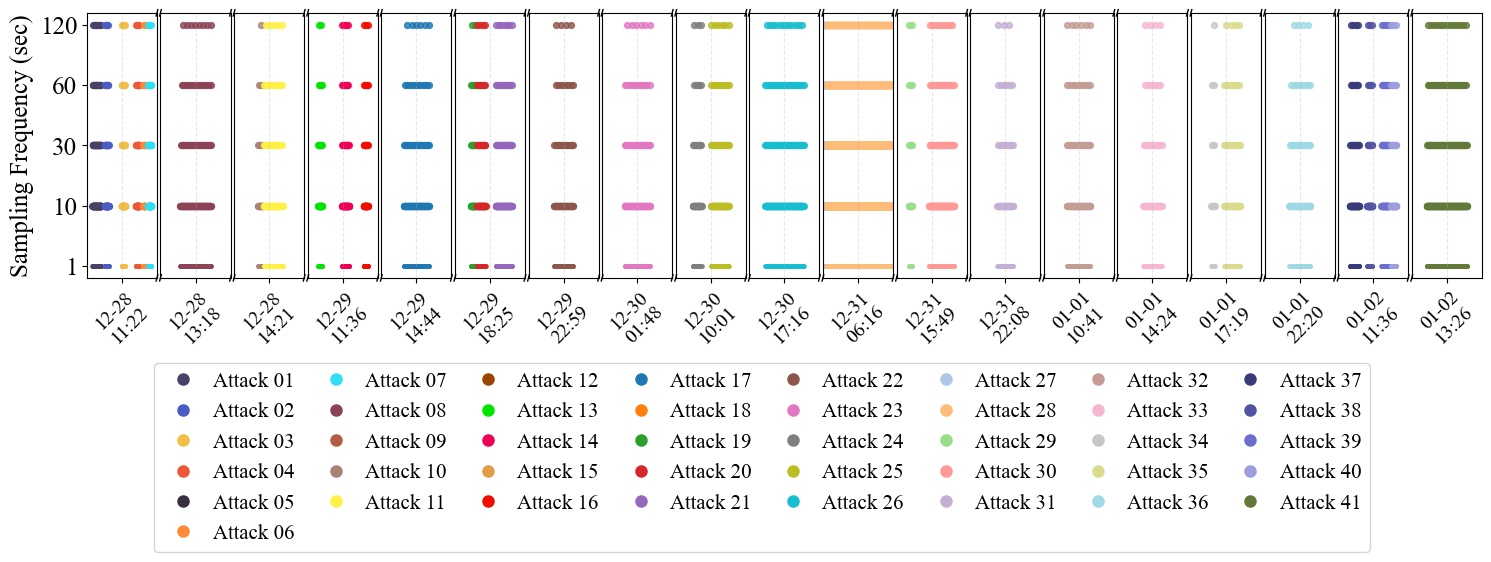

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from datetime import timedelta
import warnings

# 忽略 Matplotlib 的刻度警告
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# =========================
# 0) Matplotlib 全局字体设置
# =========================
plt.rcParams.update({
    "font.size": 18,
    "font.family": ["Times New Roman", "SimSun"],
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Times New Roman',
    'mathtext.it': 'Times New Roman:italic',
    'mathtext.bf': 'Times New Roman:bold',
})

# =========================
# 2-3) 断轴逻辑与 Segment 生成
# =========================
PAD_BEFORE = timedelta(minutes=10)
PAD_AFTER = timedelta(minutes=10)
MERGE_GAP = timedelta(minutes=5)

segments = []
for (start, end, _) in ATTACK_EVENTS_SWAT:
    segments.append((start - PAD_BEFORE, end + PAD_AFTER))

segments = sorted(segments, key=lambda x: x[0])
merged = []
for s, e in segments:
    if not merged: merged.append([s, e])
    else:
        ps, pe = merged[-1]
        if s <= pe + MERGE_GAP: merged[-1][1] = max(pe, e)
        else: merged.append([s, e])
segments = [(s, e) for s, e in merged]

# =========================
# 4) y 轴位置映射
# =========================
y_levels = {"orig": 0}
for i, sec in enumerate(DOWNSAMPLE_LIST, 1):
    y_levels[sec] = i
yticks = list(y_levels.values())
ylabels = ["1"] + [f"{sec}" for sec in DOWNSAMPLE_LIST]

# =========================
# 5) 绘图
# =========================
nseg = len(segments)
fig, axes = plt.subplots(1, nseg, figsize=(18, 5), sharey=True, gridspec_kw={"wspace": 0.05})
if nseg == 1: axes = [axes]

unique_handles, unique_labels = {}, {}

for i, (ax, (seg_start, seg_end)) in enumerate(zip(axes, segments)):
    # 绘制攻击点
    for attack_id, (start, end, _) in enumerate(ATTACK_EVENTS_SWAT, 1):
        if end < seg_start or start > seg_end: continue
        for key, y in y_levels.items():
            _df = df_test_dict[key]
            mask = (_df["Attack"] == 1) & (_df["Timestamp"] >= max(start, seg_start)) & (_df["Timestamp"] <= min(end, seg_end))
            times = _df.loc[mask, "Timestamp"]
            if len(times) == 0: continue
            ax.scatter(times, np.full(len(times), y), s=18 if key != "orig" else 6, color=attack_colors[attack_id], alpha=0.8)
        
        if attack_id not in unique_handles:
            unique_handles[attack_id] = Line2D([0], [0], marker='o', linestyle='None', markersize=8, 
                                               markerfacecolor=attack_colors[attack_id], markeredgecolor=attack_colors[attack_id])
            unique_labels[attack_id] = f"Attack {attack_id:02d}"

    ax.set_xlim(seg_start, seg_end)

    # 【核心修正】：强制每个子图在中心位置显示一个时间刻度
    center_time = seg_start + (seg_end - seg_start) / 2
    ax.set_xticks([center_time])
    # 使用两行格式：%m-%d 为月日，\n%H:%M 为换行后的时分
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
    
    # 旋转标签防止重叠
    plt.setp(ax.get_xticklabels(), rotation=45, ha="center", fontsize=14)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

# 设置Y轴
axes[0].set_yticks(yticks)
axes[0].set_yticklabels(ylabels)
axes[0].set_ylabel('Sampling Frequency (sec)')
for ax in axes[1:]: ax.tick_params(axis="y", left=False, labelleft=False)

# 断轴标记
d = 0.012
for i in range(nseg - 1):
    ax1, ax2 = axes[i], axes[i + 1]
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1)
    ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs); ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)
    kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False, linewidth=1)
    ax2.plot((-d, +d), (-d, +d), **kwargs); ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)

# 底部留白调整
fig.subplots_adjust(bottom=0.35)
fig.legend(list(unique_handles.values()), list(unique_labels.values()), loc="upper center",
           bbox_to_anchor=(0.5, 0.2), ncol=8, handletextpad=0.4, columnspacing=1.0, fontsize=15)

plt.savefig("SWaT_Final_Publication.png", dpi=300, bbox_inches='tight')
plt.show()